In [23]:
import pandas as pd
from scipy.fft import rfft, rfftfreq
import numpy as np

In [24]:
# load the data from the CSV file
data_file = 'mpu6500_data_2000Hz_2MBaud.csv'
data = pd.read_csv(data_file)
data

,pc_time,packet_counter,arduino_time_us,ax_raw,ay_raw,az_raw,gx_raw,gy_raw,gz_raw
0,1.777181e+09,786432,714196,-498,194,8230,25,121,15
1,1.777181e+09,786432,714692,-754,226,8206,26,127,17
2,1.777181e+09,786432,719192,-530,218,8212,26,119,21
3,1.777181e+09,786432,723696,-510,200,8190,30,119,21
4,1.777181e+09,786432,724192,-522,172,8232,26,120,21
...,...,...,...,...,...,...,...,...,...
3739,1.777181e+09,4294180972,1187814,103,14,-4756,67,-432,214
3740,1.777181e+09,4294180972,1187814,103,14,-4256,67,-446,230
3741,1.777181e+09,4294180972,1187822,101,14,-3752,67,-446,230
3742,1.777181e+09,4294180972,1187822,101,14,-3256,67,-472,228


In [25]:
# get avg frequency of samples
time_between_samples = data['arduino_time_us'].diff().dropna()
avg_freq = 1 / (10 ** -6 * time_between_samples.mean())
avg_freq

np.float64(13512.050019493741)

In [26]:
list(data['arduino_time_us'].diff())[0:50]

[nan,
 496.0,
 4500.0,
 4504.0,
 496.0,
 500.0,
 500.0,
 500.0,
 -3496.0,
 500.0,
 496.0,
 504.0,
 496.0,
 500.0,
 500.0,
 500.0,
 1413790.0,
 -820626.0,
 131108.0,
 -65560.0,
 -524280.0,
 -131082.0,
 0.0,
 -262120.0,
 0.0,
 524278.0,
 0.0,
 -131076.0,
 0.0,
 -131082.0,
 0.0,
 -262120.0,
 279270.0,
 500.0,
 4504.0,
 4496.0,
 504.0,
 496.0,
 500.0,
 504.0,
 -3504.0,
 508.0,
 496.0,
 496.0,
 504.0,
 496.0,
 500.0,
 504.0,
 1381786.0,
 -951692.0]

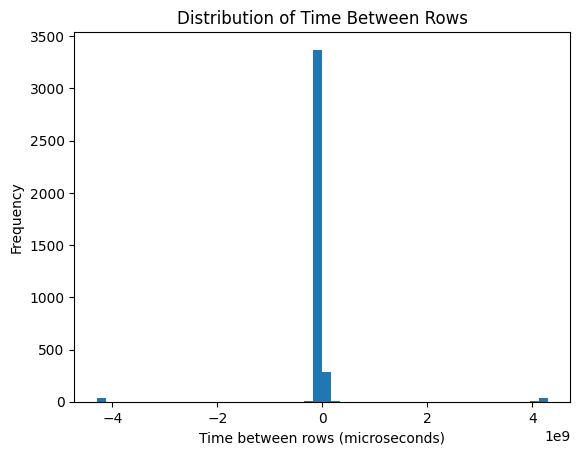

In [27]:
# plot the distribution of t_us between rows
import matplotlib.pyplot as plt
plt.hist(data['arduino_time_us'].diff().dropna(), bins=50)
plt.xlabel('Time between rows (microseconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Time Between Rows')
plt.show()

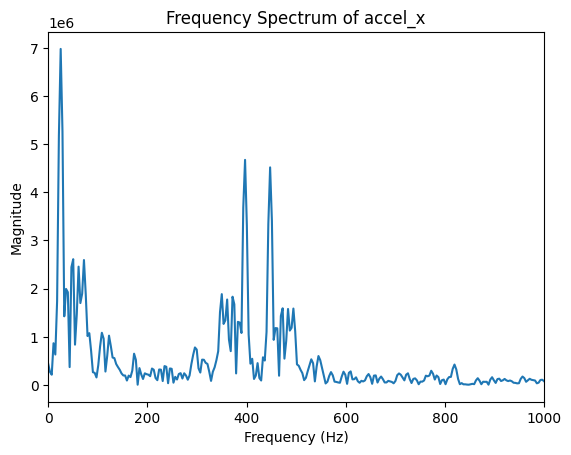

In [28]:
# perform frequency analysis on accel data
# Number of samples
N = len(data)
# Sample spacing
T = 1 / avg_freq
# Perform FFT on accel_x
yf = rfft(data['ax_raw'])
xf = rfftfreq(N, T)
plt.plot(xf, np.abs(yf))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Spectrum of accel_x')
plt.xlim(0, 1000)  # Limit x-axis to 1000 Hz
plt.show()